# **Emotion Classification/Sentimental Analysis using RNN,LSTM and GRU**

Classifying text into 6 emotions (**sadness, joy, love, anger, fear, surprise**) by comparing plain recurrent models before building an **Advanced Bidirectional GRU.**

# Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load the Dataset

Load the dair-ai/emotion dataset from Hugging Face. https://huggingface.co/datasets/dair-ai/emotion

In [2]:
from datasets import load_dataset

ds = load_dataset("dair-ai/emotion", "split")

README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.03MB            

split/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  127kB            

split/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  129kB            

split/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [3]:
train_text=ds['train']['text']
train_label=ds['train']['label']
test_text=ds['test']['text']
test_label=ds['test']['label']

In [4]:
label_names=ds['train'].features['label'].names
label_names

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

In [5]:
for i in train_label:
  print(i,label_names[i])

Streaming output truncated to the last 5000 lines.
0 sadness
0 sadness
3 anger
4 fear
2 love
1 joy
3 anger
0 sadness
0 sadness
1 joy
4 fear
1 joy
4 fear
2 love
2 love
3 anger
3 anger
0 sadness
4 fear
0 sadness
0 sadness
5 surprise
2 love
1 joy
1 joy
2 love
0 sadness
1 joy
1 joy
4 fear
0 sadness
3 anger
3 anger
0 sadness
2 love
4 fear
4 fear
3 anger
3 anger
1 joy
0 sadness
0 sadness
1 joy
1 joy
4 fear
0 sadness
1 joy
2 love
4 fear
3 anger
0 sadness
1 joy
3 anger
5 surprise
4 fear
1 joy
1 joy
2 love
4 fear
0 sadness
1 joy
3 anger
4 fear
3 anger
0 sadness
0 sadness
0 sadness
3 anger
0 sadness
4 fear
1 joy
3 anger
3 anger
0 sadness
4 fear
1 joy
3 anger
4 fear
0 sadness
1 joy
4 fear
1 joy
2 love
3 anger
4 fear
4 fear
4 fear
4 fear
1 joy
3 anger
3 anger
0 sadness
1 joy
0 sadness
1 joy
0 sadness
0 sadness
1 joy
0 sadness
4 fear
4 fear
1 joy
0 sadness
1 joy
0 sadness
1 joy
4 fear
3 anger
0 sadness
1 joy
3 anger
1 joy
1 joy
0 sadness
1 joy
1 joy
3 anger
3 anger
1 joy
1 joy
1 joy
0 sadness
1 joy

So here we need to map the label numbers with the label names

In [6]:
df_train=pd.DataFrame({
    'text':train_text,
    'label':[label_names[i] for i in train_label]
})

df_test=pd.DataFrame({
    'text':test_text,
    'label':[label_names[i] for i in test_label]
})

In [7]:
df_train

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger
...,...,...
15995,i just had a very brief time in the beanbag an...,sadness
15996,i am now turning and i feel pathetic that i am...,sadness
15997,i feel strong and good overall,joy
15998,i feel like this was such a rude comment and i...,anger


In [8]:
df_test

,text,label
0,im feeling rather rotten so im not very ambiti...,sadness
1,im updating my blog because i feel shitty,sadness
2,i never make her separate from me because i do...,sadness
3,i left with my bouquet of red and yellow tulip...,joy
4,i was feeling a little vain when i did this one,sadness
...,...,...
1995,i just keep feeling like someone is being unki...,anger
1996,im feeling a little cranky negative after this...,anger
1997,i feel that i am useful to my people and that ...,joy
1998,im feeling more comfortable with derby i feel ...,joy


In [9]:
df_train.isnull().sum()

,0
text,0
label,0


# Exploratory Data Analysis

<Axes: xlabel='label', ylabel='count'>

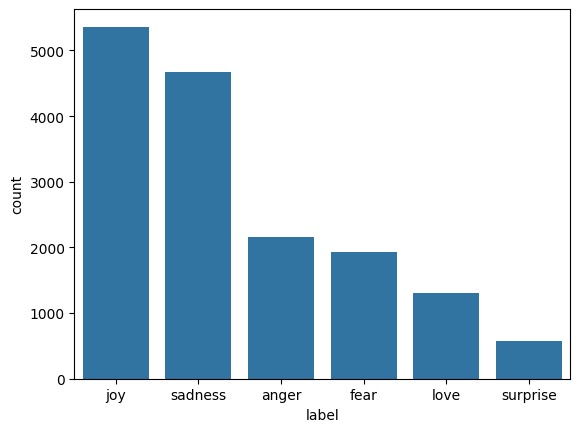

In [10]:
#visualize class distribution for all 6 emotions
sns.countplot(x='label',data=df_train,order=df_train['label'].value_counts().index)

Obviously there is a class imbalance between the multi class.We will use class_weight

# Data Preprocessing -Using NLP

Tokenize text,pad sequence to maximum length 50 and convert labels to numpy array

In [11]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
MAX_WORDS=10000

tokenizer=Tokenizer(num_words=MAX_WORDS,oov_token='<oov>')
tokenizer.fit_on_texts(df_train['text'])

train_seq=tokenizer.texts_to_sequences(df_train['text'])
test_seq=tokenizer.texts_to_sequences(df_test['text'])


train_pad=pad_sequences(train_seq,maxlen=50,padding='post',truncating='post')
test_pad=pad_sequences(test_seq,maxlen=50,padding='post',truncating='post')

train_labels_str=np.array(df_train['label'])
test_labels_str=np.array(df_test['label'])

label_to_int = {name: i for i, name in enumerate(label_names)}

train_labels = np.array([label_to_int[label] for label in train_labels_str])
test_labels = np.array([label_to_int[label] for label in test_labels_str])

num_classes=len(np.unique(train_labels))


print(f"Number of classes: {num_classes}")
print(f"Vocabulary Size: {len(tokenizer.word_index)}")
print(f"Max sentence length: {train_pad.shape[1]}")

Number of classes: 6
Vocabulary Size: 15213
Max sentence length: 50


# Shared Training Utilities

Compute balanced class weights to handle dataset skew and setup early stopping

In [12]:
from sklearn.utils import class_weight
from tensorflow.keras.callbacks import EarlyStopping

class_weights=class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

class_weight_dict = dict(enumerate(class_weights))

early_stop=EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
    )

In [13]:
class_weight_dict

{0: np.float64(0.5715102157451064),
 1: np.float64(0.49732686808404825),
 2: np.float64(2.044989775051125),
 3: np.float64(1.2351397251814111),
 4: np.float64(1.3766993632765445),
 5: np.float64(4.662004662004662)}

# Model training


**Model 1-Simple RNN**

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Embedding, Dense, Dropout, LSTM, GRU

rnn_model = Sequential([
    Embedding(input_dim = MAX_WORDS, output_dim = 128 , input_length = 50),
    SimpleRNN(units=128, return_sequences=True),
    Dropout(0.5),
    SimpleRNN(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

rnn_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [15]:
rnn_model.fit(
    train_pad,
    train_labels,
    validation_data=(test_pad, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop]
)

rnn_loss, rnn_accuracy = rnn_model.evaluate(test_pad, test_labels)
print(f"RNN Loss: {rnn_loss}")
print(f"RNN Accuracy: {rnn_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.1489 - loss: 1.9222 - val_accuracy: 0.1720 - val_loss: 1.7899
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1603 - loss: 1.8042 - val_accuracy: 0.2485 - val_loss: 1.7782
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.1618 - loss: 1.7853 - val_accuracy: 0.0980 - val_loss: 1.8221
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1556 - loss: 1.7794 - val_accuracy: 0.1630 - val_loss: 1.8000
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.1474 - loss: 1.7967 - val_accuracy: 0.2270 - val_loss: 1.7935
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2485 - loss: 1.7782
RNN Loss: 1.7782405614852905
RNN Accuracy: 0.2485000044107437


**Model 2- Standard LSTM**

In [16]:
lstm_model = Sequential([
    Embedding(input_dim = MAX_WORDS, output_dim = 128 , input_length = 50),
    LSTM(units=128, return_sequences=True),
    Dropout(0.5),
    LSTM(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

lstm_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

lstm_model.fit(
    train_pad,
    train_labels,
    validation_data=(test_pad, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop]
)

lstm_loss, lstm_accuracy = lstm_model.evaluate(test_pad, test_labels)
print(f"LSTM Loss: {lstm_loss}")
print(f"LSTM Accuracy: {lstm_accuracy}")


Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.1577 - loss: 1.7943 - val_accuracy: 0.0835 - val_loss: 1.7787
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.1604 - loss: 1.7933 - val_accuracy: 0.0805 - val_loss: 1.7870
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1718 - loss: 1.7982 - val_accuracy: 0.0795 - val_loss: 1.7867
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0835 - loss: 1.7787
LSTM Loss: 1.7787346839904785
LSTM Accuracy: 0.08349999785423279


**Model 3- Standard GRU**

In [17]:
gru_model = Sequential([
    Embedding(input_dim = MAX_WORDS, output_dim = 128 , input_length = 50),
    GRU(units=128, return_sequences=True),
    Dropout(0.5),
    GRU(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

gru_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

gru_model.fit(
    train_pad,
    train_labels,
    validation_data=(test_pad, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop]
)

gru_loss, gru_accuracy = gru_model.evaluate(test_pad, test_labels)
print(f"GRU Loss: {gru_loss}")
print(f"GRU Accuracy: {gru_accuracy}")


Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.1434 - loss: 1.7969 - val_accuracy: 0.0330 - val_loss: 1.8073
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.1349 - loss: 1.7955 - val_accuracy: 0.0795 - val_loss: 1.8091
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.1412 - loss: 1.7944 - val_accuracy: 0.0805 - val_loss: 1.7892
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0330 - loss: 1.8073
GRU Loss: 1.8073186874389648
GRU Accuracy: 0.032999999821186066


Checking the best model

In [18]:
#model and test accuracy
models = pd.DataFrame({
    'Model': ['RNN', 'LSTM', 'GRU'],
    'Loss': [rnn_loss, lstm_loss, gru_loss],
    'Accuracy': [rnn_accuracy, lstm_accuracy, gru_accuracy]
})

models.sort_values(by='Accuracy', ascending=False)

,Model,Loss,Accuracy
0,RNN,1.778241,0.2485
1,LSTM,1.778735,0.0835
2,GRU,1.807319,0.0330


**Advanced Bidirectional GRU**

In [19]:
from tensorflow.keras.layers import Bidirectional

bi_gru_model=Sequential([
    Embedding(input_dim=MAX_WORDS,output_dim=128,input_length=50),
    Bidirectional(GRU(units=128,return_sequences=True)),
    Dropout(0.5),
    Bidirectional(GRU(units=64)),
    Dropout(0.5),
    Dense(units=num_classes,activation='softmax')
])

bi_gru_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

bi_gru_model.build(input_shape=(None, 50))
bi_gru_model.summary()

bi_gru_model.fit(
    train_pad,
    train_labels,
    validation_data=(test_pad, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop]
)

bi_gru_loss, bi_gru_accuracy = bi_gru_model.evaluate(test_pad, test_labels)
print(f"Bi-GRU Loss: {bi_gru_loss}")
print(f"Bi-GRU Accuracy: {bi_gru_accuracy}")

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 50, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 50, 256)        │       198,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 50, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       123,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,602,566 (6.11 MB)

 Trainable params: 1,602,566 (6.11 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.4476 - loss: 1.2223 - val_accuracy: 0.8340 - val_loss: 0.5581
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.8934 - loss: 0.3167 - val_accuracy: 0.9030 - val_loss: 0.2777
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9328 - loss: 0.1972 - val_accuracy: 0.9130 - val_loss: 0.2800
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9511 - loss: 0.1352 - val_accuracy: 0.9135 - val_loss: 0.2538
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.9569 - loss: 0.1166 - val_accuracy: 0.9180 - val_loss: 0.2358
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.9694 - loss: 0.0826 - val_accuracy: 0.9165 - val_loss: 0.2617
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.9728 - loss: 0.0797 - val_accuracy: 0.9220 - val_loss: 0.2209
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.9792 - loss: 0.0590 - val_acc

# Overall Evaluation and Bias Analysis

In [20]:
from sklearn.metrics import classification_report, confusion_matrix

bigru_predictions = bi_gru_model.predict(test_pad)
bigru_predictions = np.argmax(bigru_predictions, axis=1)

print("Confusion Matrix:")
print(confusion_matrix(test_labels, bigru_predictions))

print("\nClassification Report:")
print(classification_report(test_labels, bigru_predictions))

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
Confusion Matrix:
[[556   3   0  12   7   3]
 [  4 640  39   4   1   7]
 [  0  18 140   1   0   0]
 [  9   4   0 252  10   0]
 [  7   1   0   0 195  21]
 [  1   2   0   0   2  61]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       581
           1       0.96      0.92      0.94       695
           2       0.78      0.88      0.83       159
           3       0.94      0.92      0.93       275
           4       0.91      0.87      0.89       224
           5       0.66      0.92      0.77        66

    accuracy                           0.92      2000
   macro avg       0.87      0.91      0.89      2000
weighted avg       0.93      0.92      0.92      2000



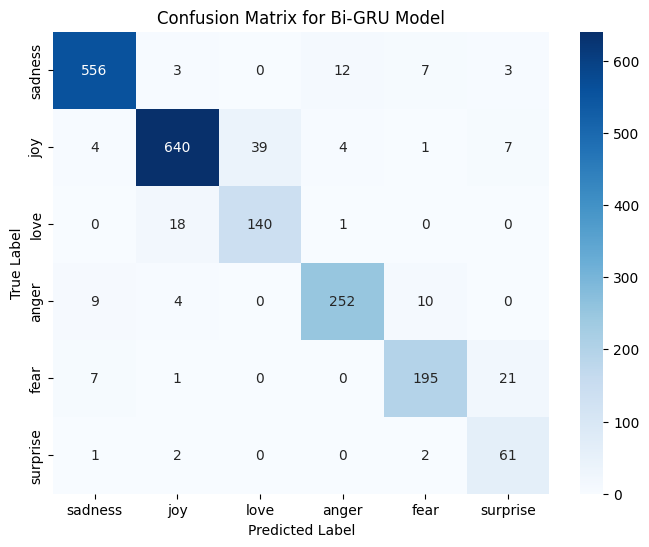

In [21]:
import matplotlib.pyplot as plt

bigru_predictions_str = [label_names[p] for p in bigru_predictions]

cm = confusion_matrix(test_labels_str, bigru_predictions_str, labels=label_names)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Bi-GRU Model')
plt.show()

# Final Predictions

In [22]:
sample_texts = [
    "I am amused by this mood",
    "I cannot stop smiling, this is the best day of my life.",
    "I feel wonderful and excited about what is coming next.",
    "I am so grateful for all the love and support I received.",

    "I feel really sad and I don't know how to deal with this pain.",
    "Everything feels empty and lonely without my best friend.",
    "I am disappointed because all my hard work went to waste.",
    "I just want to cry because today has been extremely difficult.",

    "I am furious about what happened and I cannot calm down.",
    "This is completely unfair and I am extremely angry.",
    "I hate being treated like this, it makes me so frustrated.",
    "I am so annoyed that I don't even want to talk to anyone.",

    "I am really scared about what is going to happen tomorrow.",
    "This situation makes me nervous and uncomfortable.",
    "I am terrified that something terrible might happen.",
    "I feel anxious and worried about my upcoming results.",

    "I am surprised that you actually remembered my birthday.",
    "I cannot believe we won the competition after all that hard work.",
    "I was shocked when I saw the final result.",
    "Wow, I never expected things to turn out this way!"
]


sample_pad=pad_sequences(tokenizer.texts_to_sequences(sample_texts),maxlen=50,padding='post',truncating='post')

predictions=bi_gru_model.predict(sample_pad)
predicted_labels=np.argmax(predictions,axis=1)

for i in range(len(sample_texts)):
  print(f"{sample_texts[i]}----{label_names[predicted_labels[i]]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
I am amused by this mood----joy
I cannot stop smiling, this is the best day of my life.----anger
I feel wonderful and excited about what is coming next.----joy
I am so grateful for all the love and support I received.----joy
I feel really sad and I don't know how to deal with this pain.----sadness
Everything feels empty and lonely without my best friend.----sadness
I am disappointed because all my hard work went to waste.----sadness
I just want to cry because today has been extremely difficult.----anger
I am furious about what happened and I cannot calm down.----anger
This is completely unfair and I am extremely angry.----anger
I hate being treated like this, it makes me so frustrated.----anger
I am so annoyed that I don't even want to talk to anyone.----anger
I am really scared about what is going to happen tomorrow.----fear
This situation makes me nervous and uncomfortable.----fear
I am terrified that something terrible might happen.----fear
I fe

# Saving the model

In [25]:
import os
import pickle

model_dir='Artifacts'
os.makedirs(model_dir,exist_ok=True)

model_path=os.path.join(model_dir,'bi_gru_model.h5')
tokenizer_path=os.path.join(model_dir,'tokenizer_emotion.pkl')

bi_gru_model.save(model_path)
with open(tokenizer_path,'wb') as f:
  pickle.dump(tokenizer,f,protocol=pickle.HIGHEST_PROTOCOL)